In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('..')

In [2]:
from Utils.Accuracy_measures import topk_accuracy
from Utils.TinyImageNet_loader import get_tinyimagenet_dataloaders
from Utils.Num_parameter import count_parameters
from Models.Resnet50 import Resnet50

import torchvision.transforms as transforms
from torch import nn
from torch import optim

import time
import torch
import os

In [3]:
device = 'cuda'

In [4]:
model = Resnet50(pretrained=True,
                          weights_path='../weights/resnet50_weights.pth',
                          tensorized=False,
                          input_shape=(192,192),
                          num_classes=200,
                          avg_pool=False,
                          new_classifier=None).to(device)

In [32]:
# Set up the transforms and train/test loaders
image_size = 192

tiny_transform_train = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.Resize((image_size, image_size)), 
            transforms.RandomCrop(image_size, padding=5),
            transforms.RandomRotation(10),
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])
tiny_transform_val = transforms.Compose([
            transforms.Resize((image_size, image_size)), 
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])
tiny_transform_test = transforms.Compose([
            transforms.Resize((image_size, image_size)), 
            transforms.ToTensor(),
            transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
        ])


train_loader, test_loader, _ = get_tinyimagenet_dataloaders(
                                                        data_dir = '../datasets',
                                                        transform_train=tiny_transform_train,
                                                        transform_val=tiny_transform_val,
                                                        transform_test=tiny_transform_test,
                                                        batch_size=64,
                                                        image_size=192)

In [33]:
for x,y in train_loader:
    break

x.shape

torch.Size([10, 3, 192, 192])

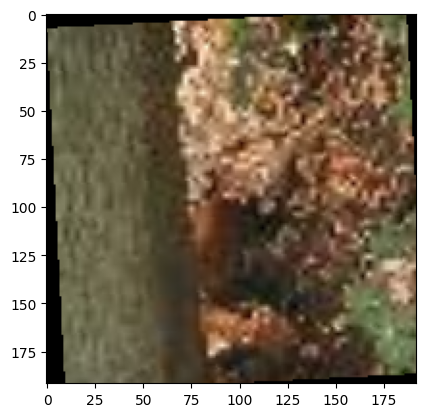

In [34]:
import matplotlib.pyplot as plt

plt.imshow(x[0].T)

In [35]:
model

_resnet50(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0): Conv2d(6

In [36]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam([
    {'params': model.classifier.parameters(), 'lr': 0.001},
    {'params': model.features.parameters(), 'lr': 0.0001},
    {'params': model.avgpool.parameters(), 'lr': 0.0001},
])

In [8]:
def test(loader, epoch):
    model.eval()
    
    start_time = time.time()
    running_loss = 0.0
    correct = {1:0.0, 2:0.0, 3:0.0, 4:0.0, 5:0.0} # set the initial correct count for top1-to-top5 accuracy

    for _, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)
            
        outputs = model(inputs)
        loss = criterion(outputs, targets)

        running_loss += loss.item()
        accuracies = topk_accuracy(outputs, targets, topk=(1, 2, 3, 4, 5))
        for k in accuracies:
            correct[k] += accuracies[k]['correct']

    elapsed_time = time.time() - start_time
    top1_acc, top2_acc, top3_acc, top4_acc, top5_acc = [(correct[k]/len(loader.dataset)) for k in correct]
    avg_loss = running_loss / len(loader.dataset)
    
    report_test = f'Test epoch {epoch}: top1={top1_acc}%, top2={top2_acc}%, top3={top3_acc}%, top4={top4_acc}%, top5={top5_acc}%, loss={avg_loss}, time={elapsed_time}s'
    print(report_test)

    return report_test

In [9]:
def train(loader, epoch):
    model.train()
    
    start_time = time.time()
    running_loss = 0.0
    correct = {1:0.0, 2:0.0, 3:0.0, 4:0.0, 5:0.0} # set the initial correct count for top1-to-top5 accuracy

    for _, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        accuracies = topk_accuracy(outputs, targets, topk=(1, 2, 3, 4, 5))
        for k in accuracies:
            correct[k] += accuracies[k]['correct']

    elapsed_time = time.time() - start_time
    top1_acc, top2_acc, top3_acc, top4_acc, top5_acc = [(correct[k]/len(loader.dataset)) for k in correct]
    avg_loss = running_loss / len(loader.dataset)
    
    report_train = f'Train epoch {epoch}: top1={top1_acc}%, top2={top2_acc}%, top3={top3_acc}%, top4={top4_acc}%, top5={top5_acc}%, loss={avg_loss}, time={elapsed_time}s'
    print(report_train)

    return report_train

In [10]:
# t1 = train(tiny_train_loader, 1)
# t2 = train(tiny_train_loader, 2)
# t3 = train(tiny_train_loader, 3)
# t4 = train(tiny_train_loader, 4)
# t5 = train(tiny_train_loader, 5)
# t6 = train(tiny_train_loader, 6)
# torch.save(model.state_dict(), '../weights/temp.pth')

In [9]:
r1 = test(tiny_train_loader, 1)

Test epoch 1: top1=0.6495499610900879%, top2=0.7680400013923645%, top3=0.8234099745750427%, top4=0.856909990310669%, top5=0.8799699544906616%, loss=0.020699929400682448, time=107.10854196548462s


In [10]:
r = test(tiny_val_loader, 1)

Test epoch 1: top1=0.5031999945640564%, top2=0.626800000667572%, top3=0.6893999576568604%, top4=0.7295999526977539%, top5=0.7616999745368958%, loss=0.03343069446086883, time=9.804478168487549s
